In [ ]:
# stdlib pathlib (filesystem paths)
from pathlib import Path

# src/utils/pathing.py
from src.utils.pathing import ensure_repo_root_on_sys_path  # src/utils/pathing.py

ensure_repo_root_on_sys_path(Path.cwd())

# Unsupervised Learning

This module covers unsupervised learning concepts, focusing on dimensionality reduction techniques like Principal Component Analysis (PCA).

## Learning Objectives

- Understand unsupervised learning concepts
- Perform dimensionality reduction with PCA
- Visualize high-dimensional data in lower dimensions

**What is Unsupervised Learning?**
Unsupervised learning finds patterns in data without labels. Unlike supervised learning (which learns from labeled examples), unsupervised learning discovers hidden structure.

**Key Techniques:**
- **Clustering**: Group similar data points together
- **Dimensionality Reduction**: Reduce number of features while preserving information
- **Anomaly Detection**: Find unusual data points

**Why Dimensionality Reduction?**
- **Visualization**: Can't visualize data with more than 3 dimensions
- **Noise Reduction**: Remove less important features
- **Speed**: Fewer features = faster computation
- **Storage**: Less data to store


Original data shape: (150, 4)

Explained variance ratio: [0.92461872 0.05306648]
Total variance explained: 0.978


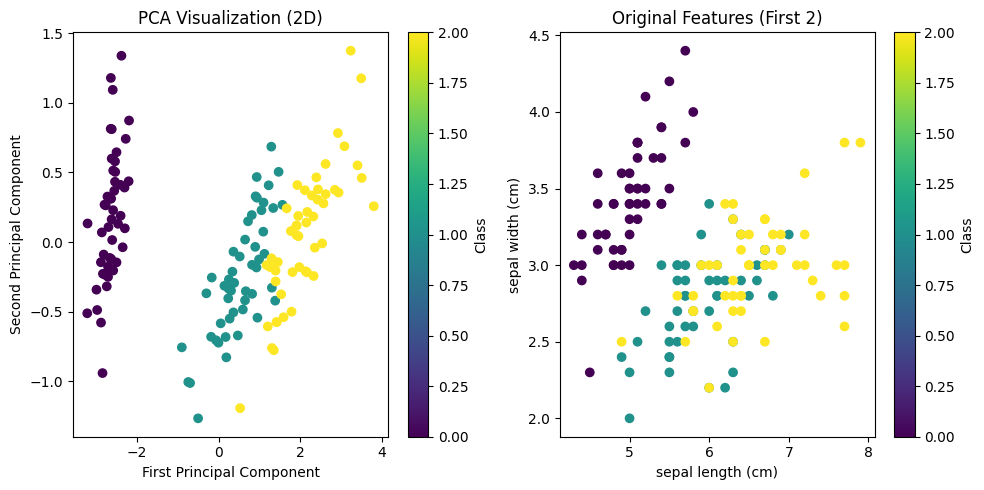

In [ ]:
# ============================================
# IMPORTING LIBRARIES: Setting Up Our Tools
# ============================================

# Scikit-learn: Machine learning library
from sklearn.datasets import load_iris  # Iris flower dataset

# Our custom utility functions
from src.models.unsupervised import perform_pca  # PCA dimensionality reduction

# Visualization and data manipulation
import matplotlib.pyplot as plt  # Plotting library
import pandas as pd  # Data manipulation

# ============================================
# LOADING THE DATASET: Iris Flowers
# ============================================

# load_iris() loads the Iris flower dataset
# We'll use this to demonstrate dimensionality reduction
iris = load_iris()  # Returns a Bunch object

# X = Features (inputs): Flower measurements (4 dimensions)
# iris.data contains feature values (150 samples × 4 features)
# We convert to DataFrame for easier manipulation
X = pd.DataFrame(iris.data, columns=iris.feature_names)
# Features: sepal length, sepal width, petal length, petal width (4 measurements)

# y = Target labels (for visualization only - not used in PCA)
# iris.target contains class labels (0, 1, or 2)
y = iris.target  # Class labels: 0=setosa, 1=versicolor, 2=virginica

print("Original data shape:", X.shape)  # Output: (150, 4) - 150 flowers, 4 features

# ============================================
# DIMENSIONALITY REDUCTION: Principal Component Analysis (PCA)
# ============================================

# PCA finds new axes (principal components) that capture most variance
# n_components=2: Reduce from 4 dimensions to 2 dimensions
# This allows us to visualize the data in 2D

# perform_pca() performs PCA transformation
# X.values converts DataFrame to NumPy array (required by PCA)
X_pca, pca = perform_pca(X.values, n_components=2)
# Returns:
# - X_pca: Transformed data in 2D (150 samples × 2 components)
# - pca: The fitted PCA model (can transform new data)

# ============================================
# EXPLAINED VARIANCE: How Much Information is Preserved?
# ============================================

# explained_variance_ratio_ shows how much variance each component captures
# [0.925, 0.053] means:
# - First component captures 92.5% of variance
# - Second component captures 5.3% of variance
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")

# Total variance explained = sum of all component variances
# 0.978 means 97.8% of original information is preserved in 2D
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.3f}")
# Higher is better (1.0 = 100% preserved, but we only have 2 components)

# ============================================
# VISUALIZATION: Comparing PCA vs Original Features
# ============================================

# Create figure with 2 subplots side by side
plt.figure(figsize=(10, 5))  # Width=10 inches, height=5 inches

# Subplot 1: PCA visualization (2D projection)
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1 (left)

# Scatter plot: X_pca[:, 0] = first principal component, X_pca[:, 1] = second principal component
# c=y colors points by true class labels (for comparison)
# cmap='viridis' is a color scheme
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('First Principal Component')  # X-axis: first PC (captures most variance)
plt.ylabel('Second Principal Component')  # Y-axis: second PC (captures second-most variance)
plt.title('PCA Visualization (2D)')  # Chart title
plt.colorbar(label='Class')  # Color legend showing class labels

# Subplot 2: Original features (first 2 features only)
plt.subplot(1, 2, 2)  # 1 row, 2 columns, position 2 (right)

# Scatter plot using original features (first 2 features)
# X.iloc[:, 0] = first original feature, X.iloc[:, 1] = second original feature
# This shows what we'd see if we just picked 2 features arbitrarily
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='viridis')
plt.xlabel(iris.feature_names[0])  # X-axis: first feature name (e.g., "sepal length (cm)")
plt.ylabel(iris.feature_names[1])  # Y-axis: second feature name (e.g., "sepal width (cm)")
plt.title('Original Features (First 2)')  # Chart title
plt.colorbar(label='Class')  # Color legend

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()  # Display both plots

# Interpretation:
# - Left plot (PCA): Optimized 2D view that preserves most information
# - Right plot (Original): Arbitrary 2D view using first 2 features
# - If classes are better separated in left plot, PCA found better representation
# - PCA components are linear combinations of original features
